In [3]:
%load_ext autoreload
%autoreload 2

import sys

PROJECT = "/Users/Guille/Desktop/dynamic_update/functional_forecast_dynamic_update"

sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from skfda import FDataGrid
from skfda.exploratory.depth import IntegratedDepth, ModifiedBandDepth

from matplotlib_scalebar.scalebar import ScaleBar

from src import loader, plotter

from src.config import DATA, DEPTH, IMAGES, VALIDATION, TABLES
from src.fda import _fDepth, _fQuantile
from src.utils import KS, get_band_fraction, get_hyper, mask_intervals

from src.fdu import functional_dynamic_update

# Loading color palette
palette_ = pd.read_csv(DATA / "palette.csv")

# Loading Texas map
_TX = gpd.read_file(DATA / "maps/TX/State.shp")

T = 288
method = "fusion"
resource = "wind"
aggregation = "asset"

# Update seasonal and spatial distance with similarity metric and lambda parameters
# kappa_0 to the code first neighborhood threshold
# Remove xi and gamma

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

In [4]:
(
    F_tr_,
    F_ts_,
    E_tr_,
    E_ts_,
    X_tr_,
    X_ts_,
    T_tr_,
    T_ts_,
    assets_tr_,
    assets_ts_,
    t_tr_,
    t_ts_,
    dt_,
    dx_,
) = loader.preprocessed_dataset(
    unbiased = True,
    path_to_training_data = DATA / "preprocessed_wind_2017.pkl",
    path_to_testing_data = DATA / "preprocessed_wind_2018.pkl",
    T = 288,
)

print(F_tr_.shape, F_ts_.shape)
print(E_tr_.shape, E_ts_.shape)
print(X_tr_.shape, X_ts_.shape)
print(T_tr_.shape, T_ts_.shape)
print(assets_tr_.shape, assets_ts_.shape)
print(t_tr_.shape, t_ts_.shape)
print(dt_.shape, dx_.shape)

E_tr_lin_, E_ts_lin_ = loader.processed_dataset(
    unbiased = True,
    path_to_training_data = DATA / "linear_preprocessed_wind_2017.pkl",
    path_to_testing_data = DATA / "linear_preprocessed_wind_2018.pkl",
    T = 288,
)

print(E_tr_lin_.shape, E_ts_lin_.shape)

E_tr_biased_, E_ts_biased_ = loader.processed_dataset(
    unbiased = False,
    path_to_training_data = DATA / "preprocessed_wind_2017.pkl",
    path_to_testing_data = DATA / "preprocessed_wind_2018.pkl",
    T = 288,
)

print(E_tr_biased_.shape, E_ts_biased_.shape)

(67881, 288) (364, 288, 187)
(67881, 288) (364, 288, 187)
(67881, 2) (187, 2)
(67881, 288) (364, 288)
(67881, 1) (187,)
(67881,) (364,)
(288,) (288,)
(67881, 288) (364, 288, 187)
(67881, 288) (364, 288, 187)


In [11]:
# wind unbiased-025 {72: 1, 144: 4, 216: 1}
# wind biased-025 {72: 2, 144: 1, 216: 2}
exp_description="unbiased-025-1"
_init = {72: 1, 144: 2, 216: 1}

exp_description="unbiased-025-2"
_init = {72: 1, 144: 3, 216: 3}

exp_description="unbiased-025-3"
_init = {72: 1, 144: 2, 216: 2}

exp_description="unbiased-025-6"
_init = {72: 3, 144: 4, 216: 1}

# exp_description="biased-025"
# _init = {72: 5, 144: 2, 216: 1}

hyper_, envelope_ = loader.hyperparameters(
    _init,
    resource,
    method,
    aggregation,
    exp_description,
    path_to_validation = VALIDATION,
)

hyper_.loc['length_scale_f'] = 1./hyper_.loc['tau']
hyper_.loc['length_scale_e'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_e']
hyper_.loc['length_scale_d'] = hyper_.loc['length_scale_f']*hyper_.loc['rho_d']
print(hyper_)
# print(envelope_)

stats_, funcs_ = loader.get_asset_stats(
    _init, 
    resource, 
    method, 
    aggregation, 
    exp_description, 
    T, 
    VALIDATION, 
)
# print(stats_)
# print(funcs_)

time                   72           144          216
p_fusion          0.750000     0.750000     0.750000
forget_rate_f     0.125000     0.125000     0.125000
forget_rate_e     1.000000     1.000000     1.000000
lookahead_rate    4.000000     4.000000     4.000000
tau               0.010000     0.010000     0.010000
kappa           150.000000   150.000000   150.000000
rho_e             0.604503     0.193503     0.412193
rho_d             0.082507     0.014069     0.000643
kappa_0         150.000000  2166.000000  2282.000000
nu                6.000000     5.000000     9.000000
sigma             0.188068     0.157037     0.121467


In [4]:
df_fmt, latex = loader.error_scores(
    _init,
    resource, 
    method,
    aggregation,
    exp_description,
    VALIDATION,
)
# print(latex)

# df_fmt, latex = loader.envelope_scores(
#     envelope_, 
#     alphas = (0.1, 0.2),
# )
# print(df_fmt)

df_fmt, latex = loader.envelope_scores_old(
    envelope_, 
    alphas = [0.1, 0.2],
)
print(df_fmt)

              FIS                             FCS                            \
              MBD         fknn        ECDF    MBD         fknn         ECDF   
            score  frac  score frac  score  score  frac  score  frac  score   
time alpha                                                                    
72   0.1    0.566  0.55  0.575  0.2  0.533  0.914  0.60  0.910  0.20  0.911   
     0.2    0.476  0.35  0.491  0.1  0.449  0.819  0.35  0.828  0.10  0.826   
144  0.1    0.668  0.70  0.634  0.2  0.622  0.907  0.65  0.907  0.20  0.919   
     0.2    0.570  0.45  0.542  0.1  0.535  0.820  0.45  0.825  0.10  0.834   
216  0.1    0.652  0.75  0.673  0.2  0.614  0.906  0.70  0.907  0.15  0.920   
     0.2    0.544  0.55  0.580  0.1  0.522  0.811  0.50  0.858  0.10  0.833   

              SCP                           
              MBD         fknn        ECDF  
            score  frac  score frac  score  
time alpha                                  
72   0.1    0.739  1.00  0.72

In [5]:
              FIS                              FCS                            \
              MBD         fknn         ECDF    MBD         fknn         ECDF   
            score  frac  score  frac  score  score  frac  score  frac  score   
time alpha                                                                     
72   0.1    0.568  0.60  0.570  0.60  0.533  0.912  0.60  0.905  0.60  0.902   
     0.2    0.475  0.35  0.477  0.35  0.447  0.815  0.35  0.806  0.35  0.814   
144  0.1    0.661  0.70  0.672  0.70  0.598  0.908  0.65  0.907  0.70  0.915   
     0.2    0.563  0.45  0.565  0.45  0.505  0.823  0.45  0.800  0.45  0.831   
216  0.1    0.688  0.75  0.696  0.75  0.653  0.908  0.70  0.917  0.75  0.917   
     0.2    0.584  0.55  0.587  0.55  0.549  0.810  0.50  0.824  0.55  0.833   

              SCP                            
              MBD         fknn         ECDF  
            score  frac  score  frac  score  
time alpha                                   
72   0.1    0.732  1.00  0.713  1.00  0.288  
     0.2    0.732  1.00  0.713  1.00  0.112  
144  0.1    0.779  1.00  0.735  1.00  0.428  
     0.2    0.779  1.00  0.735  1.00  0.235  
216  0.1    0.885  1.00  0.850  1.00  0.553  
     0.2    0.826  0.95  0.786  0.95  0.348 

SyntaxError: invalid syntax (1517164922.py, line 1)

In [ ]:
# The same region, different day, for a given interval (eg, 144), low and high scores.
interval = 144   # or "144" if your columns are strings
df_score = stats_.copy()
df_funcs = funcs_.copy()

df_score = df_score.loc[
    ((df_funcs[interval] < 1. ) & (df_funcs[interval] > .9 ))
].reset_index(drop = True)

# Lowest score day for each region
idx_low = df_score.groupby("region")[interval].idxmin()
low_df = df_score.loc[idx_low].rename(
    columns={"day": "low_day", interval: "low_score"}
)
low_df = low_df[["region", "low_day", "low_score"]]
print(low_df.shape)

# Highest score day for each region
idx_high = df_score.groupby("region")[interval].idxmax()

high_df = df_score.loc[idx_high].rename(
    columns={"day": "high_day", interval: "high_score"}
)
high_df = high_df[["region", "high_day", "high_score"]]
print(high_df.shape)

summary = low_df.merge(high_df, on="region")
summary["difference"] = summary["high_score"] - summary["low_score"]
summary = summary.sort_values("region", ascending=False).reset_index(drop=True)
print(summary)

In [ ]:
# The same region, same day, growing scores across intervals (72, 144, 216).
df_score = stats_.copy()
df_funcs = funcs_.copy()
intervals_ = keys = list(_init.keys())

df_score = df_score.loc[
    ((df_funcs[interval] < 1. ) & (df_funcs[interval] > .5 ))
].reset_index(drop = True)

# Strictly decreasing score
growing_df = df_score[
    ((df_score[intervals_[0]] >= df_score[intervals_[1]]) 
    & (df_score[intervals_[1]] >= df_score[intervals_[2]]))
].copy()

growing_df["increase_1"] = growing_df[intervals_[0]] - growing_df[intervals_[1]]
growing_df["increase_2"] = growing_df[intervals_[1]] - growing_df[intervals_[2]]
growing_df["increase"]   = growing_df[["increase_1", "increase_2"]].min(axis=1)

growing_df = growing_df.sort_values("increase", ascending=False).reset_index(drop=True)

print(growing_df)

In [ ]:
# # Two regions, same day, low and high scores for the same interval (eg, 144).
# df_score = stats_.copy()
# interval = intervals_[0]

# # Lowest-score region for each day
# idx_low = df_score.groupby("day")[interval].idxmin()

# # Highest-score region for each day
# idx_high = df_score.groupby("day")[interval].idxmax()

# low_df = df_score.loc[idx_low].rename(columns={"region": "low_region", interval: "low_score"})
# low_df = low_df[["day", "low_region", "low_score"]]

# high_df = df_score.loc[idx_high].rename(columns={"region": "high_region", interval: "high_score"})
# high_df = high_df[["day", "high_region", "high_score"]]

# summary = low_df.merge(high_df, on="day")
# summary["difference"] = summary["high_score"] - summary["low_score"]
# summary = summary.sort_values("difference", ascending=False).reset_index(drop=True)
# print(summary)

# Functional kNNs dynamic update

2336.0
0.757143551261922 149.7307127319535
Blanco Canyon Wind 2018-01-16 12:00:00
[0 1] [ 597 1739]
wind-18-15-144-asset


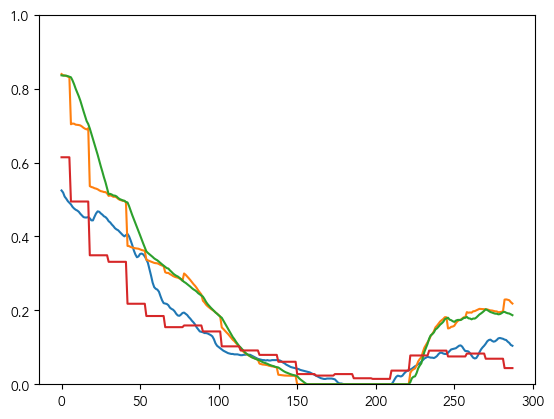

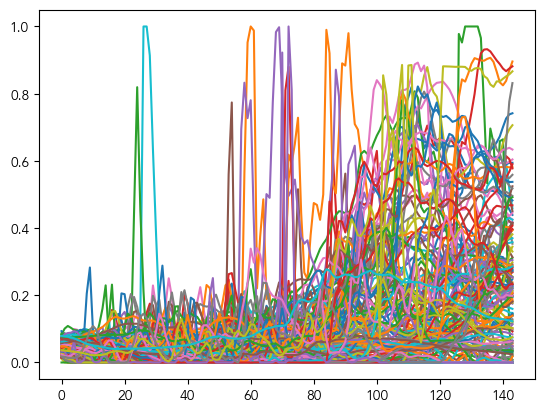

In [25]:
# Blue Summit 2018-01-06 12:00:00
# [0 1 2] [ 165 1838   16] 0.32089993194505706
# (2019,) (67881,) (2019,) (150,)
# Blanco Canyon 18 112 in 176
# Black Jack Creek Wind 17 289

#  12 348

day = 15
asset = 18              
interval = 144

_fdu = functional_dynamic_update(
    _distances = {"temporal": "seasonal_equinox", 
                  "spatial": "haversine", 
                  "fusion": "dynamic"},
    name = assets_ts_[asset],
    date = T_ts_[day, interval],
)

# Filter solar hours with loading solar set
interval_mask = mask_intervals(
    F_tr_, 
    E_tr_biased_, 
    t_tr_, 
    day, 
    day_window = 7,
)
n_mask = interval_mask.sum()
_fdu.fit(
    F_tr_,
    E_tr_lin_,
    dt_,
    X_ = X_tr_,
    t_ = t_tr_,
    interval_mask = interval_mask,
    n_samples_per_hour = 12,
)
M_ = _fdu.predict(
    F_ts_[day, :interval, asset], 
    E_ts_lin_[day, :, asset], 
    X_ts_[asset, :], 
    t_ts_[day],
    forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
    forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
    lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
    length_scale_f = get_hyper(hyper_, "length_scale_f", interval)/2.5,
    length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
    length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
    sigma = get_hyper(hyper_, "sigma", interval),
    nu = get_hyper(hyper_, "nu", interval),
    kappa_0 = get_hyper(hyper_, "kappa_0", interval),
    kappa = get_hyper(hyper_, "kappa", interval),
    p_fusion = get_hyper(hyper_, "p_fusion", interval),
)
print(get_hyper(hyper_, "kappa_0", interval))
# print(_fdu.idx_x_.shape)
print(_fdu.xi, _fdu.ess)
x_, y_ = np.unique(_fdu.arg_fed_[_fdu.idx_fed_], return_counts=True)
print(_fdu.name, _fdu.date)
print(x_, y_)

# Plotting variables
e_biased_ = E_ts_biased_[day, :, asset]
f_hat_ = F_ts_[day, interval:, asset]
e_lin_ = E_ts_lin_[day, :, asset]
x_ts_ = X_ts_[asset, :]
e_ = E_ts_[day, :, asset]
f_ = F_ts_[day, :interval, asset]

file_name = f"{resource}-{asset}-{day}-{interval}-asset"
print(file_name)

plt.figure()
plt.plot(F_ts_[day, :, asset])
plt.plot(e_)
plt.plot(e_lin_)
plt.plot(e_biased_)
plt.ylim(0, 1)
plt.show()

plt.figure()
plt.plot(M_.T)
plt.show()

In [73]:
# interval = 144

# for asset in range(10, 20):
    
#     for day in range(360):
        
#         _fdu = functional_dynamic_update(
#             _distances = {"temporal": "seasonal_equinox", 
#                           "spatial": "haversine", 
#                           "fusion": "dynamic"},
#             name = assets_ts_[asset],
#             date = T_ts_[day, interval],
#         )
        
#         # Filter solar hours with loading solar set
#         interval_mask = mask_intervals(
#             F_tr_, 
#             E_tr_biased_, 
#             t_tr_, 
#             day, 
#             day_window = 7,
#         )
        
#         _fdu.fit(
#             F_tr_,
#             E_tr_lin_,
#             dt_,
#             X_ = X_tr_,
#             t_ = t_tr_,
#             interval_mask = interval_mask,
#             n_samples_per_hour = 12,
#         )
#         M_ = _fdu.predict(
#             F_ts_[day, :interval, asset], 
#             E_ts_lin_[day, :, asset], 
#             X_ts_[asset, :], 
#             t_ts_[day],
#             forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
#             forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
#             lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
#             length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
#             length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
#             length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
#             sigma = get_hyper(hyper_, "sigma", interval),
#             nu = get_hyper(hyper_, "nu", interval),
#             kappa_0 = get_hyper(hyper_, "kappa_0", interval),
#             kappa = get_hyper(hyper_, "kappa", interval),
#             p_fusion = get_hyper(hyper_, "p_fusion", interval),
#         )
#         # print(_fdu.idx_fed_)
#         # print(_fdu.idx_x_.shape)
#         #print(np.exp(_fdu.xi), _fdu.r, _fdu.d_max)
#         x_, y_ = np.unique(_fdu.arg_fed_[_fdu.idx_fed_], return_counts=True)
#         if (x_.shape[0] == 3) & (M_.mean() > 0.2):
#             if (y_[2] > 150):
    
#                 print(asset, day)
#                 print(x_, y_, M_.mean())
    
#                 _fig, _ax = plt.subplots(figsize=(7.5, 6.25), constrained_layout=True)
                
#                 plotter.selected_scenarios_heatmap(
#                     _fig, 
#                     _ax, 
#                     palette_,
#                     _fdu._haversine_dist, 
#                     _fdu.idx_fed_, 
#                     _fdu.idx_x_local_,
#                     _fdu.d_x_,
#                     _fdu.x_, 
#                     T_tr_[:, interval], 
#                     X_ts_,
#                     _fdu.date,
#                     colorbar = True,
#                 )
                            
#                 plt.show()
                
# # Plotting variables
# e_biased_ = E_ts_biased_[day, :, asset]
# f_hat_ = F_ts_[day, interval:, asset]
# e_lin_ = E_ts_lin_[day, :, asset]
# x_ts_ = X_ts_[asset, :]
# e_ = E_ts_[day, :, asset]
# f_ = F_ts_[day, :interval, asset]

# file_name = f"{resource}-{asset}-{day}-{interval}-asset"
# print(file_name)
# # 10 167
# # 10 337
# # 11 23
# # 11 340
# # 12 43
# # 12 213
# # 13 23
# # 13 205
# # 13 350
# # 14 343
# # 15 169
# # 15 319
# # 16 12
# # 16 23
# # 16 124
# # 16 212
# # 16 295
# # 17 5
# # 17 352
# # 18 43
# # 19 182
# # 19 202
# # 19 226
# # 19 340
# plt.figure()
# plt.plot(F_ts_[day, :, asset])
# plt.plot(e_)
# plt.plot(e_lin_)
# plt.plot(e_biased_)
# plt.ylim(0, 1)
# plt.show()

# plt.figure()
# plt.plot(M_.T)
# plt.show()

In [13]:
print(M_int_.shape, F_tr_.shape)
print(F_tr_[_fdu.idx_x_, :interval].shape)

(150, 217) (67881, 288)
(150, 72)


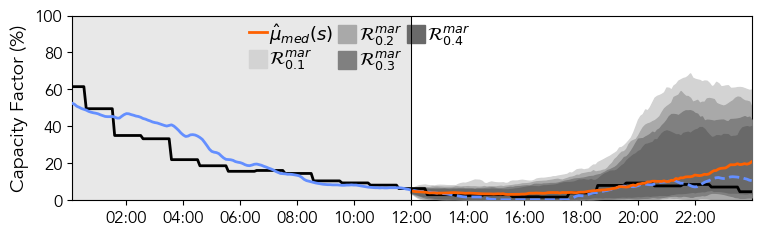

In [27]:
# Calculate confidence intervals from Directional Quantiles
alpha_ = [0.1, 0.2, 0.3, 0.4]
M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    #n_basis=20,
    n_basis=int(1.333*(T - interval)/12),
)

f_median_ext_, _upper, _lower = _fdu.ecdf_confidence_bands(
    M_int_, 
    alpha_
)

f_wmedian_ext_, _wupper, _wlower = _fdu.weighted_ecdf_confidence_region(
    M_int_, 
    _fdu.w_prime_,
    alpha_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_envelope(
    _fig, 
    _ax, 
    palette_,
    _wupper, 
    _wlower, 
    f_wmedian_ext_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color_med = palette_.loc[3, "ibm"],
    CR=r"$\mathcal{{R}}^{{mar}}_{{{}}}$",
    label = r"$\hat{\mu}_{med} (s)$",
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

plt.savefig(IMAGES / f"median_mar_bands-{file_name}.pdf")

plt.show()

(139, 144)


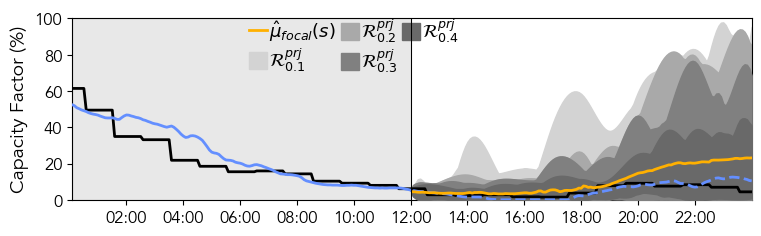

In [57]:
# Samples in each confidence band
score = 'FCS'
distance = "fknn"
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=1, 
    n_basis=int(1.333*(T - interval)/12),
)

J_ = _fdu.focal_curve_envelope_v2(
    _depth, 
    M_int_, 
    distance
)
print(J_.shape)

k_ = get_band_fraction(
    envelope_, 
    alpha_, 
    interval, 
    distance, 
    score
)
k_ = [1., 0.75, 0.5, .25]
f_focal_ext_, _upper, _lower = _fdu.focal_envelope_confidence_region(
    alpha_, 
    k_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_focal_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color_med = palette_.loc[4, "ibm"],
    label = r"$\hat{\mu}_{focal} (s)$",
    CR=r"$\mathcal{{R}}^{{prj}}_{{{}}}$",
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

plt.savefig(IMAGES / f"focal_curve_prj_bands-{file_name}.pdf")

plt.show()

# Visualization Utils

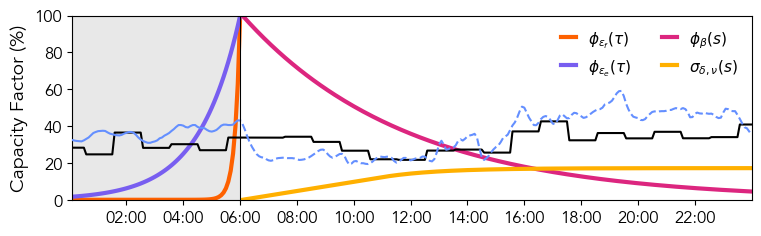

In [12]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_forecast_parameters(
    _fig, 
    _ax, 
    palette_,
    _fdu.phi_, 
    _fdu.psi_, 
    _fdu.eta_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    labels_1 = False,
    labels_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)
#plt.savefig(IMAGES / f"hyper-{file_name}.pdf")

plt.show()

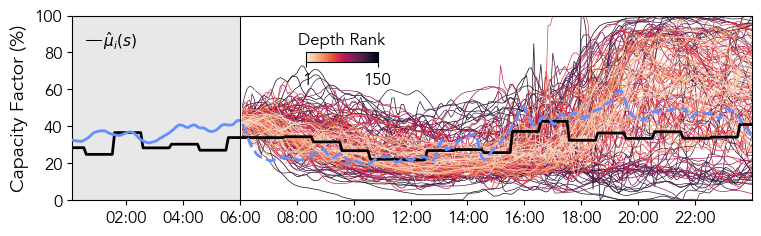

In [13]:
distance = 'MBD'
_depth = ModifiedBandDepth()

M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    #n_basis=20,
    n_basis=int(1.333*(T - interval)/12),

)

depth_score_, depth_rank_ = _fdu.get_depth(_depth, M_int_)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_depth(
    _fig, _ax, palette_,
    M_, f_, f_hat_, e_biased_, depth_score_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    colorbar_pos = [500, 75, 150, 5],
    colorbar = True,
    labels_1 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

plt.savefig(IMAGES / f"ranking-{distance}_{file_name}.pdf")

plt.show()

In [14]:
# # Calculate confidence intervals from Directional Quantiles
# f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
#     M_int_, 
#     depth_score_
# )

# _fig, _ax = plt.subplots(
#     figsize=(7.5, 2.25), 
#     constrained_layout=True
# )

# plotter.plot_enhanced_functional_boxplot(
#     _fig, _ax, palette_,
#     _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
#     dt_ = dt_ + 5, 
#     interval = interval,
#     n = 120,
#     range_ = [0, 287],
#     legend_1 = False,
#     legend_2 = False,
# )

# _ax.legend(frameon = False,
#            #loc = (0.025, .8),
#            fontsize = 11,
#            columnspacing = 0.5,
#            handletextpad = 0.2,
#            ncol = 1)

# plt.savefig(IMAGES / f"fboxplot-{distance}_{file_name}.pdf")

# plt.show()

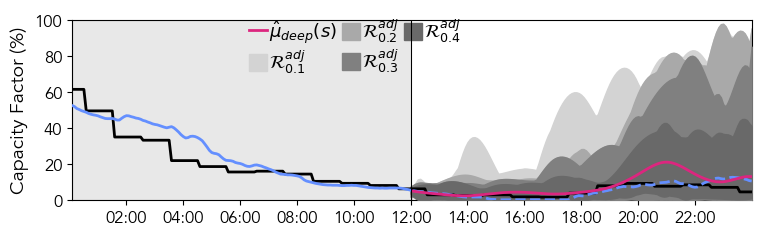

In [59]:
# Samples in each confidence band
score = 'FCS'
distance = 'MBD'
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()


M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=int(1.333*(T - interval)/12),
)

k_ = get_band_fraction(
    envelope_, 
    alpha_, 
    interval, 
    distance, 
    score
)

k_ = [1., 0.75, 0.5, .25]

f_deepest_ext_, _upper, _lower = _fdu.adjusted_functional_confidence_region(
    _depth, 
    M_int_, 
    alpha_, 
    k_
)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color_med = palette_.loc[2, "ibm"],
    label = r"$\hat{\mu}_{deep} (s)$",
    CR=r"$\mathcal{{R}}^{{adj}}_{{{}}}$",
    range_ =[0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

plt.savefig(IMAGES / f"{distance}_adj_bands-{file_name}.pdf")

plt.show()

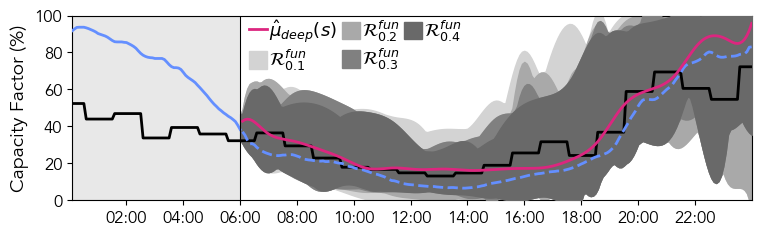

In [98]:
# Samples in each confidence band
score = 'FCS'
distance = 'MBD'
alpha_ = [0.1, 0.2, 0.3, 0.4]
_depth = ModifiedBandDepth()


M_int_, M_int_ds_ = _fdu.functional_downsampling(
    subsample=12, 
    n_basis=int(1.333*(T - interval)/12),
)

f_deepest_ext_, _upper, _lower = _fdu.functional_confidence_region(
    _depth, 
    M_int_, 
    alpha_, 
)

_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_envelope(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    color_med = palette_.loc[2, "ibm"],
    label = r"$\hat{\mu}_{deep} (s)$",
    CR=r"$\mathcal{{R}}^{{fun}}_{{{}}}$",
    range_ =[0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

plt.savefig(IMAGES / f"{distance}_fun_bands-{file_name}.pdf")

plt.show()

NameError: name 'f_wmedian_ext_' is not defined

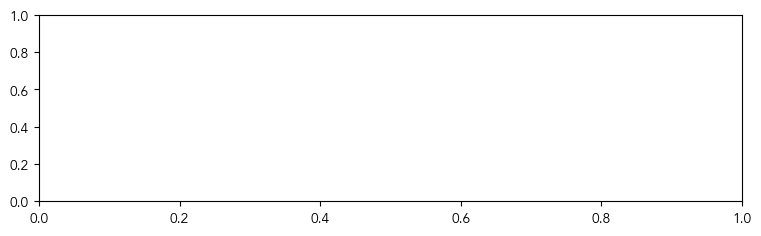

In [44]:
_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_density_heatmap(
    _fig, 
    _ax, 
    palette_,
    M_, 
    f_wmedian_ext_, 
    f_deepest_ext_, 
    f_focal_ext_,
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5,
    interval = interval,
    range_ = [0, 287],
    colorbar_pos = [50, 75, 150, 5],
    colorbar = False,
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
   loc = (0.01, .01),
   #loc = 'upper center',
   fontsize = 11,
   columnspacing = 0.25,
   handletextpad = 0.125,
   labelspacing = 0.125,
   ncol = 3
)

plt.savefig(IMAGES / f"heatmap-{file_name}.pdf")

plt.show()

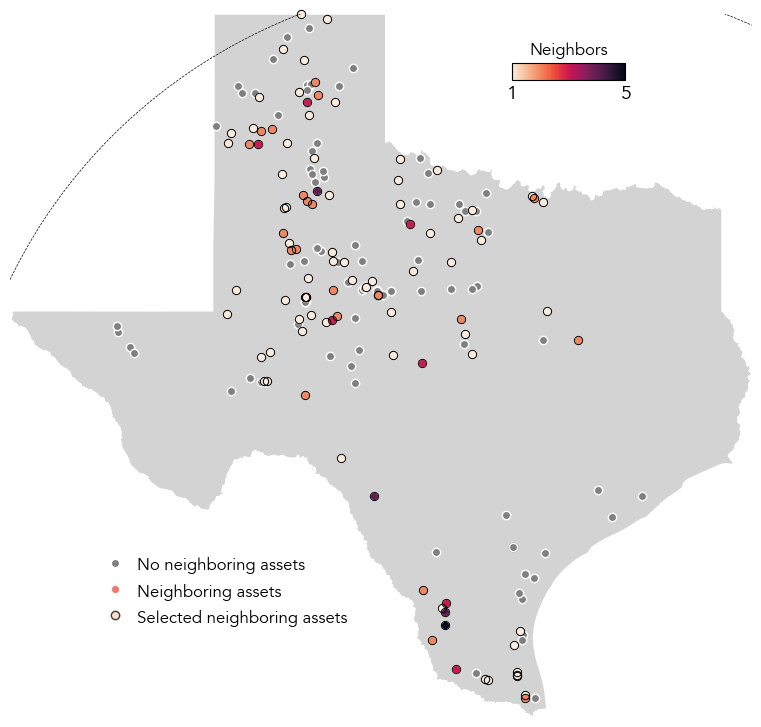

In [18]:
_fig, _ax = plt.subplots(figsize=(7.5, 7.5), constrained_layout=True)

plotter.plot_frequency_map(
    _fig, _ax, palette_, _TX, _fdu, X_tr_, X_ts_, 
    _fdu.x_, 
    _fdu.idx_fed_,
    _fdu.idx_x_, 
    _fdu.r,
)

_ax.legend(
    frameon = False, 
    bbox_to_anchor = (0.475, 0.25), 
    ncol = 1, 
    fontsize = 12
)

plt.savefig(IMAGES / f"spatial_neiboring_assets-{file_name}.pdf")

plt.show()

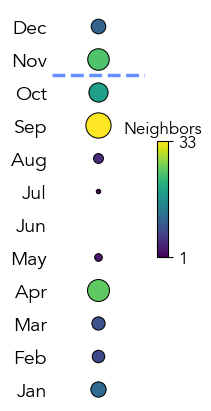

In [781]:
_fig, _ax = plt.subplots(figsize=(2, 4), constrained_layout=True)

plotter.scenarios_frequency_dates(
    _fig, 
    _ax, 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_,
    T_tr_[:, interval], 
    _fdu.date,
    scale = 10,
    colorbar = True,
)

plt.savefig(IMAGES / f"temporal_neiboring_assets-{file_name}.pdf")

plt.show()

(150,) (67881,) (150,) (150,)


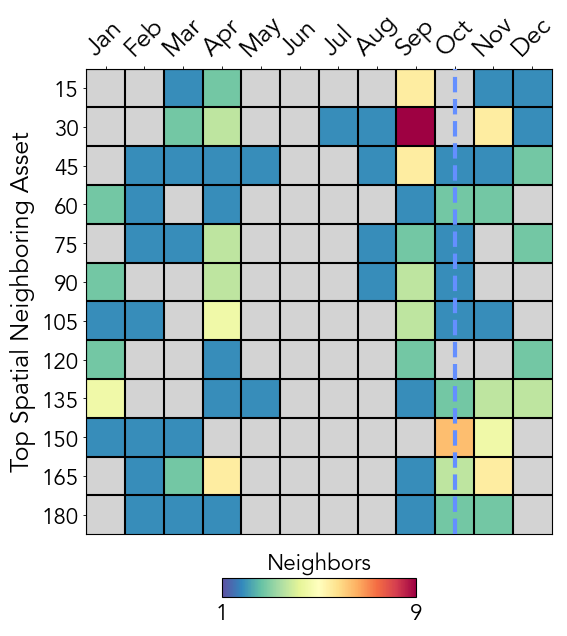

In [751]:
_fig, _ax = plt.subplots(figsize=(7.5, 6.25), constrained_layout=True)

plotter.selected_scenarios_heatmap(
    _fig, 
    _ax, 
    palette_,
    _fdu._haversine_dist, 
    _fdu.idx_fed_, 
    _fdu.idx_x_local_,
    _fdu.d_x_,
    _fdu.x_, 
    T_tr_[:, interval], 
    X_ts_,
    _fdu.date,
    colorbar = True,
)

plt.savefig(IMAGES / f"seasonly_neiboring_assets-{file_name}.pdf")

plt.show()

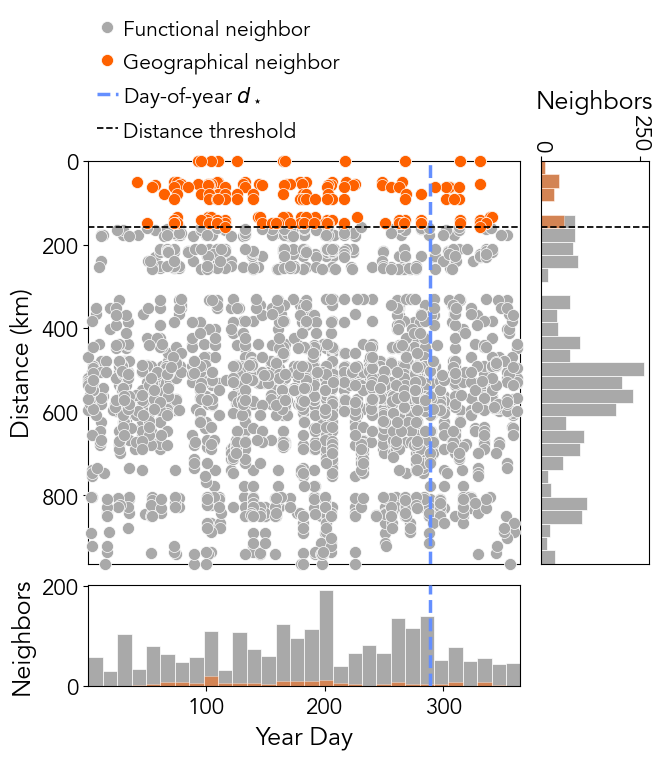

In [746]:
_fig, _ax = plt.subplot_mosaic(
    [["A", "B"], ["C", "."]],
    figsize=(6.5, 7.5),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(1, 0.25), height_ratios=(1, 0.25)),
)

plotter.plot_filtered_scenarios(
    _fig, 
    _ax["A"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_,
    t_tr_, 
    t_ts_[day], 
    _fdu.r,
)

plotter.plot_distance_histogram(
    _fig, 
    _ax["B"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_, 
    _fdu.r,
)

plotter.plot_dates_histogram(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.d_x_,
    t_tr_, 
    t_ts_[day], 
)

_ax["A"].legend(
    frameon = False,
    ncol = 1,
    columnspacing = 0.625,
    handletextpad = 0.25,
    loc = (0.0, 1.025),
    fontsize = 15,
)

plt.savefig(IMAGES / f"kNN_frequency-{file_name}.pdf")

plt.show()

0.5893596192323725


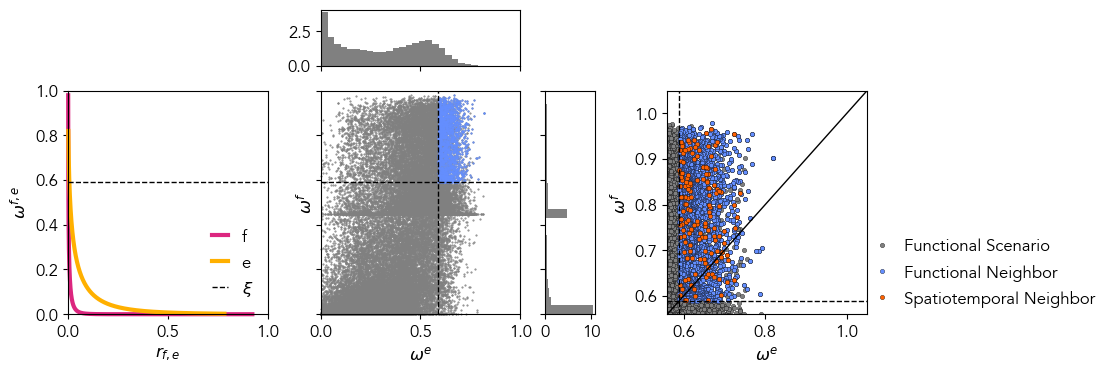

In [61]:
_fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, 
    _ax["A"], 
    palette_, 
    _fdu.d_f_, 
    _fdu.d_e_, 
    _fdu.w_f_, 
    _fdu.w_e_, 
    _fdu.xi,
    label1 = 'f',
    label2 = 'e',
    ylabel = r"$\omega^{f,e}$",
    xlabel = r"$r_{f,e}$",
)

plotter.plot_functional_neighborhood(
    _fig, 
    _ax["B"], 
    _ax["e"], 
    _ax["f"], 
    palette_, 
    _fdu.idx_fed_, 
    _fdu.w_e_, 
    _fdu.w_f_, 
    _fdu.xi,
    xlabel = r"$\omega^{e}$",
    ylabel = r"$\omega^{f}$",
)

plotter.plot_selected_functional_neighbors(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.w_e_, 
    _fdu.w_f_, 
    _fdu.xi,
    xlabel = r"$\omega^{e}$",
    ylabel = r"$\omega^{f}$",
)

_ax["C"].legend(
    frameon = False, 
    fontsize = 12, 
    ncol = 1, 
    loc = (1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor_fe-{file_name}.pdf")

plt.show()

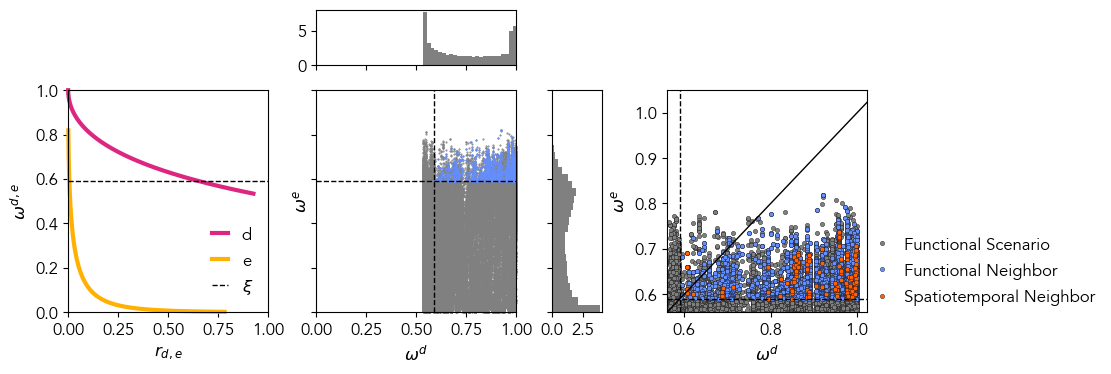

In [62]:
_fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, 
    _ax["A"], 
    palette_, 
    _fdu.d_d_, 
    _fdu.d_e_, 
    _fdu.w_d_, 
    _fdu.w_e_, 
    _fdu.xi,
    label1 = 'd',
    label2 = 'e',
    ylabel = r"$\omega^{d,e}$",
    xlabel = r"$r_{d,e}$",
)

plotter.plot_functional_neighborhood(
    _fig, 
    _ax["B"], 
    _ax["e"], 
    _ax["f"], 
    palette_, 
    _fdu.idx_fed_, 
    _fdu.w_d_, 
    _fdu.w_e_, 
    _fdu.xi,
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{e}$",
)

plotter.plot_selected_functional_neighbors(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.w_d_, 
    _fdu.w_e_, 
    _fdu.xi,
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{e}$",
)

_ax["C"].legend(
    frameon = False, 
    fontsize = 12, 
    ncol = 1, 
    loc = (1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor_ed-{file_name}.pdf")

plt.show()

13117.343513870048


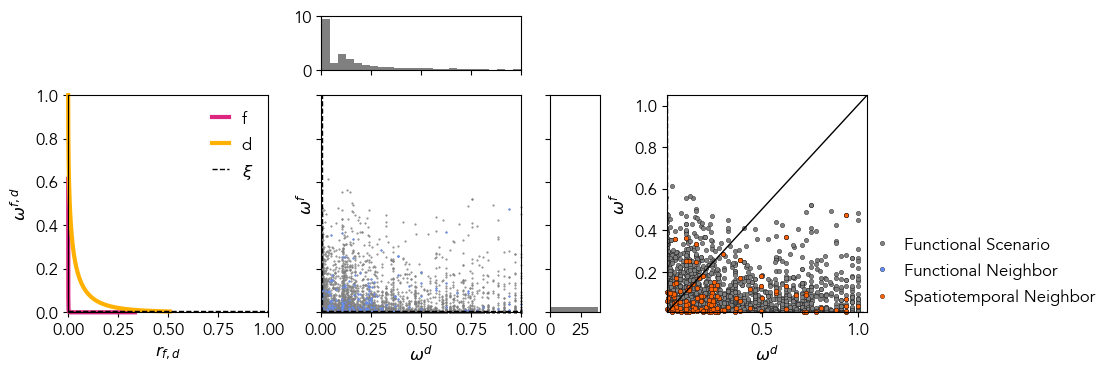

In [19]:
_fig, _ax = plt.subplot_mosaic(
    [[".", ".", "e", ".", ".", "."],
     ["A", "A", "B", "f", "C", "C"],
     ["A", "A", "B", "f", "C", "C"],],
    figsize=(11, 3.625),
    layout="constrained",
    gridspec_kw=dict(width_ratios=(2, 2, 4, 1, 2, 2), height_ratios=(1, 2, 2)),
)

plotter.plot_density_threshold(
    _fig, 
    _ax["A"], 
    palette_, 
    _fdu.d_f_, 
    _fdu.d_d_, 
    _fdu.w_f_, 
    _fdu.w_d_, 
    _fdu.xi,
    label1 = 'f',
    label2 = 'd',
    ylabel = r"$\omega^{f,d}$",
    xlabel = r"$r_{f,d}$",
)
plotter.plot_functional_neighborhood(
    _fig, 
    _ax["B"], 
    _ax["e"], 
    _ax["f"], 
    palette_, 
    _fdu.idx_fed_, 
    _fdu.w_d_, 
    _fdu.w_f_, 
    _fdu.xi,
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{f}$",
)
print(_fdu.w_d_.sum())
plotter.plot_selected_functional_neighbors(
    _fig, 
    _ax["C"], 
    palette_,
    _fdu.idx_fed_, 
    _fdu.idx_x_local_, 
    _fdu.w_d_, 
    _fdu.w_f_, 
    _fdu.xi,
    xlabel = r"$\omega^{d}$",
    ylabel = r"$\omega^{f}$",
)

_ax["C"].legend(
    frameon = False, 
    fontsize = 12, 
    ncol = 1, 
    loc = (1.0, 0.0)
)

plt.savefig(IMAGES / f"fneighbor_df-{file_name}.pdf")

plt.show()

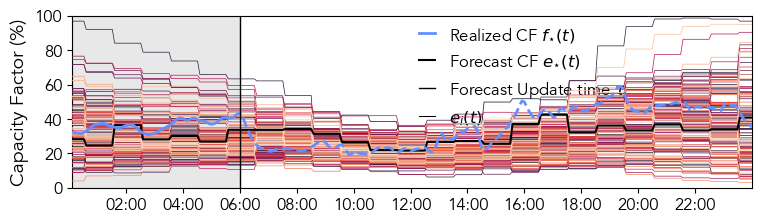

In [20]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_forecasts(
    _fig, 
    _ax, 
    palette_, 
    E_tr_biased_, 
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    range_ = [0, 287],
    n = 120,
    legend_1 = True,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

#plt.savefig(IMAGES / f"dayahead_neighbors-{file_name}.pdf")

plt.show()

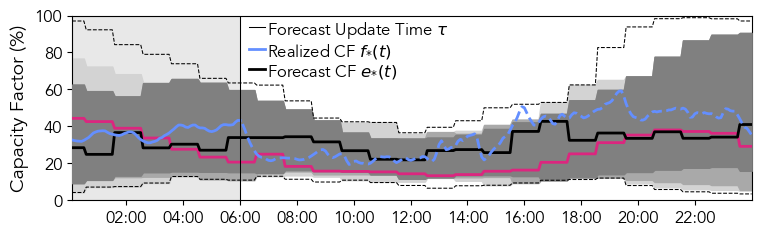

In [21]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    E_tr_biased_[_fdu.idx_x_, :], 
    depth_score_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    CR=r"$\mathcal{{R}}^{{bxp}}_{{\alpha={}}}$",
    n = 120,
    range_ = [0, 287],
    legend_1 = True,
    legend_2 = False,
    colorbar=True,
    colorbar_pos = [150, 75, 150, 5],
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

plt.savefig(IMAGES / f"fboxplot_forecast-{distance}_{file_name}.pdf")

plt.show()

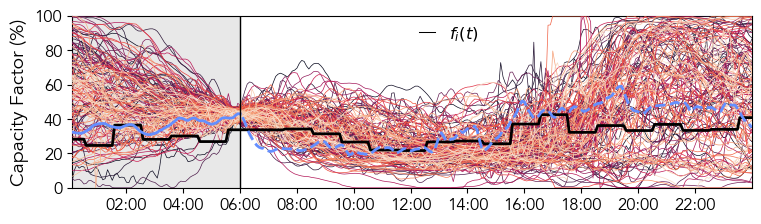

In [753]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_neighbors(
    _fig, 
    _ax, 
    palette_, 
    F_tr_, 
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    legend_1 = True,
    legend_2 = False,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)
#plt.savefig(IMAGES / f"partial_neighbors-{file_name}.pdf")

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


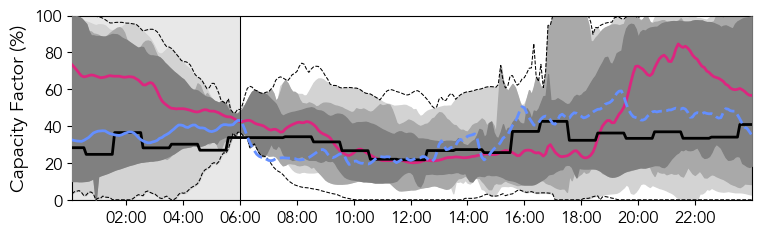

In [22]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    F_tr_[_fdu.idx_x_, :], 
    depth_score_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    CR=r"$\mathcal{{R}}^{{bxp}}_{{\alpha={}}}$",
    n = 120,
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = False,
    colorbar=True,
    colorbar_pos = [150, 75, 150, 5],
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

plt.savefig(IMAGES / f"fboxplot_realized-{distance}_{file_name}.pdf")

plt.show()

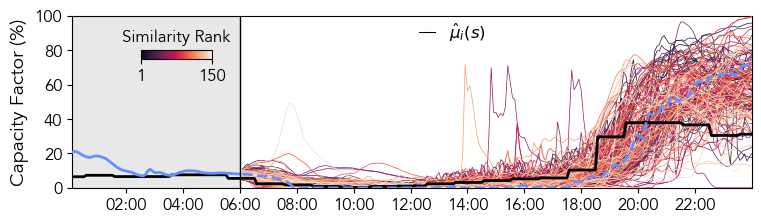

In [625]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_updates(
    _fig, 
    _ax, 
    palette_, 
    M_, 
    f_, 
    f_hat_, 
    e_biased_, 
    _fdu.w_fed_, 
    _fdu.idx_x_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    n = 120,
    range_ = [0, 287],
    legend_1=True,
    legend_2=False,
    colorbar=True,
    colorbar_pos = [150, 75, 150, 5],
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

plt.savefig(IMAGES / f"dynamic_update_neighbors-{file_name}.pdf")

plt.show()

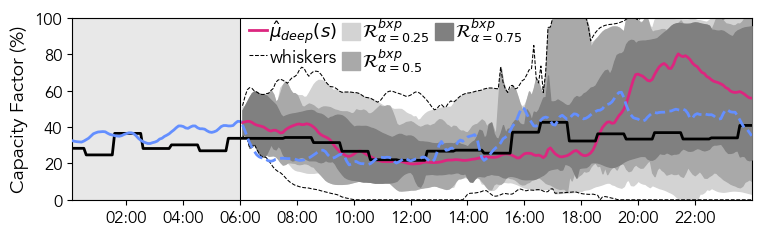

In [24]:
# Calculate confidence intervals from Directional Quantiles
f_deepest_ext_, _upper, _lower = _fdu.functional_boxplot(
    M_, 
    depth_score_
)

_fig, _ax = plt.subplots(
    figsize=(7.5, 2.25), 
    constrained_layout=True
)

plotter.plot_enhanced_functional_boxplot(
    _fig, _ax, palette_,
    _upper, _lower, f_deepest_ext_, f_, f_hat_, e_biased_, dx_,
    dt_ = dt_ + 5, 
    interval = interval,
    CR=r"$\mathcal{{R}}^{{bxp}}_{{\alpha={}}}$",
    n = 120,
    range_ = [0, 287],
    legend_1 = False,
    legend_2 = True,
)

_ax.legend(
    frameon = False,
    loc = (0.25, .65),
    #loc = 'lower center',
    fontsize = 13,
    columnspacing = 0.25,
    handletextpad = 0.125,
    labelspacing = 0.125,
    ncol = 3
)

plt.savefig(IMAGES / f"fboxplot_fused-{distance}_{file_name}.pdf")

plt.show()

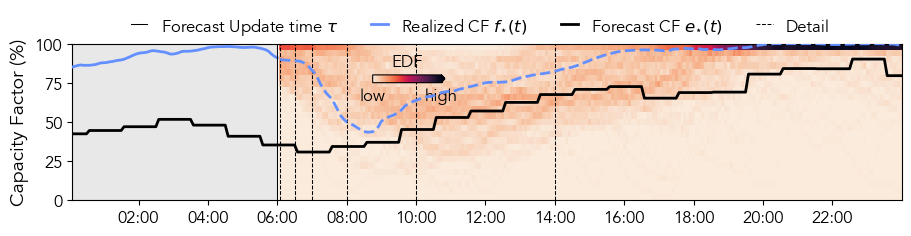

In [80]:
slices_ = [6, 12, 24, 48, 96]

_fig, _ax = plt.subplots(figsize=(9, 2.25), constrained_layout=True)

plotter.plot_heatmap_slices(
    _fig, 
    _ax, 
    palette_, 
    _fdu.M_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_ = dt_ + 5, 
    interval = interval,
    slices_ = slices_,
    range_ = [0, 287],
    n = 120,
    colorbar = True,
)

_ax.legend(
    loc = (0.0625, 1), 
    frameon = False, 
    fontsize = 12, 
    ncol = 4
)

plt.savefig(IMAGES / f"heatmap_cutoffs-{file_name}.pdf")

plt.show()

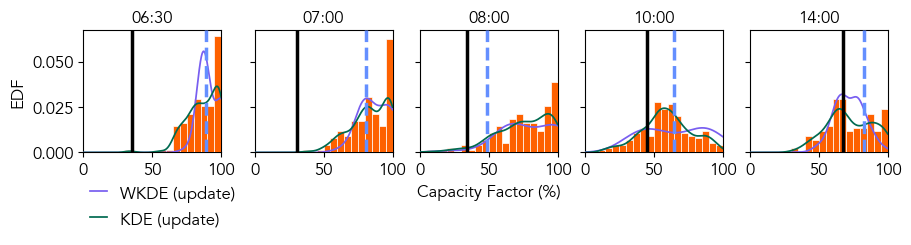

In [81]:
WKDs_ = _fdu.weighted_kernel_density_estimation(
    100*M_, 
    weights = _fdu.w_fed_[_fdu.idx_x_local_],
    algorithm = "auto", 
    kernel = "gaussian",
)

KDs_ = _fdu.kernel_density_estimation(
    100*M_, 
    algorithm = "auto", 
    kernel = "gaussian",
)

_fig, _ax = plt.subplots(
    1, len(slices_), 
    figsize = (9, 2.25), 
    sharey = True, 
    layout = "constrained"
)

plotter.plot_histogram_cuts(
    _fig, 
    _ax, 
    palette_, 
    WKDs_, 
    KDs_,
    M_, 
    f_, 
    f_hat_, 
    e_biased_, 
    dx_, 
    dt_, 
    interval, 
    slices_)

_ax[0].legend(
    frameon = False, 
    fontsize = 12, 
    loc = (0, -.675)
)

plt.savefig(IMAGES / f"marginal_density_cutoffs-{file_name}.pdf")

plt.show()

In [59]:
F_curves_ = []
M_curves_ = []
D_curves_ = []
for interval in range(6, 282, 6):

    M_ = _fdu.predict(
        F_ts_[day, :interval, asset],
        E_ts_lin_[day, :, asset],
        X_ts_[asset, :],
        t_ts_[day],
        forget_rate_f = get_hyper(hyper_, "forget_rate_f", interval),
        forget_rate_e = get_hyper(hyper_, "forget_rate_e", interval),
        lookahead_rate = get_hyper(hyper_, "lookahead_rate", interval),
        length_scale_f = get_hyper(hyper_, "length_scale_f", interval),
        length_scale_e = get_hyper(hyper_, "length_scale_e", interval),
        length_scale_d = get_hyper(hyper_, "length_scale_d", interval),
        sigma = get_hyper(hyper_, "sigma", interval),
        nu = get_hyper(hyper_, "nu", interval),
        kappa_0 = get_hyper(hyper_, "kappa_0", interval),
        kappa = get_hyper(hyper_, "kappa", interval),
        p_fusion = get_hyper(hyper_, "p_fusion", interval),
    )

    # Compute depth to find the focal curve
    _F = FDataGrid(data_matrix=_fdu.M_, grid_points=_fdu.dt_[interval:])

    depth_rank_ = np.argsort(_depth(_F))[::-1]

    M_curves_.append(np.median(_fdu.M_, axis=0))
    F_curves_.append(_fdu.f_focal_)
    D_curves_.append(_fdu.M_[depth_rank_[0], :])

print(len(F_curves_), len(M_curves_), len(D_curves_))

NameError: name '_depth' is not defined

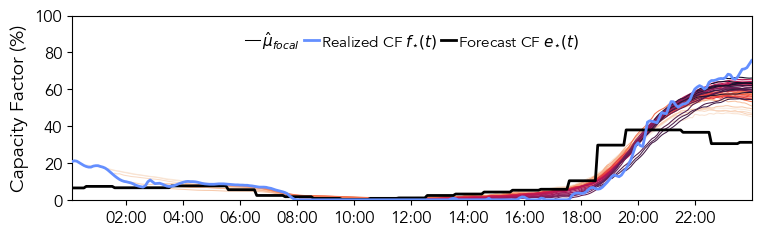

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


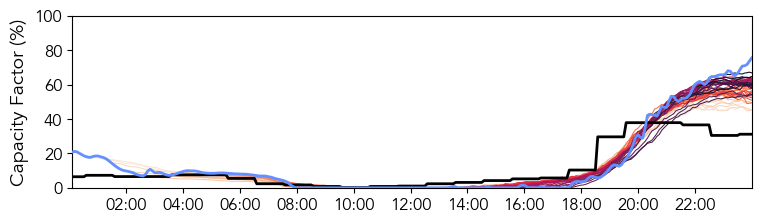

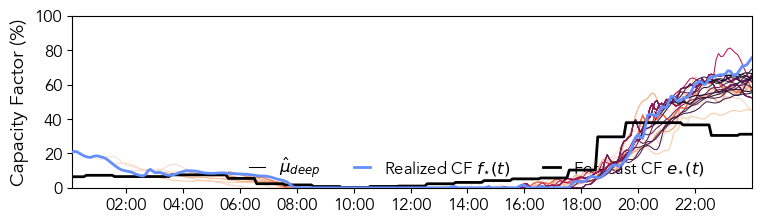

In [402]:
_fig, _ax = plt.subplots(figsize=(7.5, 2.25), constrained_layout=True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    F_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5,
    label = r"$\hat{\mu}_{focal}$",
    range_ = [0, 287],
    legend = True,
    colorbar = False,
)

_ax.legend(frameon = False,
           #loc = (0.4125, -.035),
           loc = 'upper center',
           fontsize = 11,
           columnspacing = 0.25,
           handletextpad = 0.125,
           labelspacing = 0.1,
           ncol = 3)

plt.savefig(IMAGES / f"dynamic_update-focal_curve-{file_name}.pdf")

plt.show()

_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    M_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5, 
    range_ = [0, 287],
    legend = False,
    colorbar = False,
    label = r"$\hat{\mu}_{med}$"
)

_ax.legend(
    #loc = (0.25, -0.1), 
    frameon = False, 
    fontsize = 12, 
    ncol = 3,
)

plt.savefig(IMAGES / f"dynamic_update-median_curve-{file_name}.pdf")

plt.show()

_fig, _ax = plt.subplots(figsize=(7.5, 2.125), constrained_layout=True)

plotter.plot_dynamic_update(
    _fig, _ax, palette_, 
    D_curves_, f_, f_hat_, e_biased_, dx_, dt_ + 5, 
    range_ = [0, 287],
    legend = True,
    colorbar = False,
    label = r"$\hat{\mu}_{deep}$"
)

_ax.legend(
    loc = (0.25, 0.0), 
    frameon = False, 
    fontsize = 12, 
    ncol = 3
)

plt.savefig(IMAGES / f"dynamic_update-deepest_curve-{file_name}.pdf")

plt.show()

(67881,) (172,) (2345, 2) (172, 2)


 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:844: ShapelyDeprecationWarning:__len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:855: ShapelyDeprecationWarning:Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 /Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:850: ShapelyDeprecationWarning:__getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
 <__array_function__ internals>:5: ShapelyDeprecationWarning:The array interface is deprecated and will

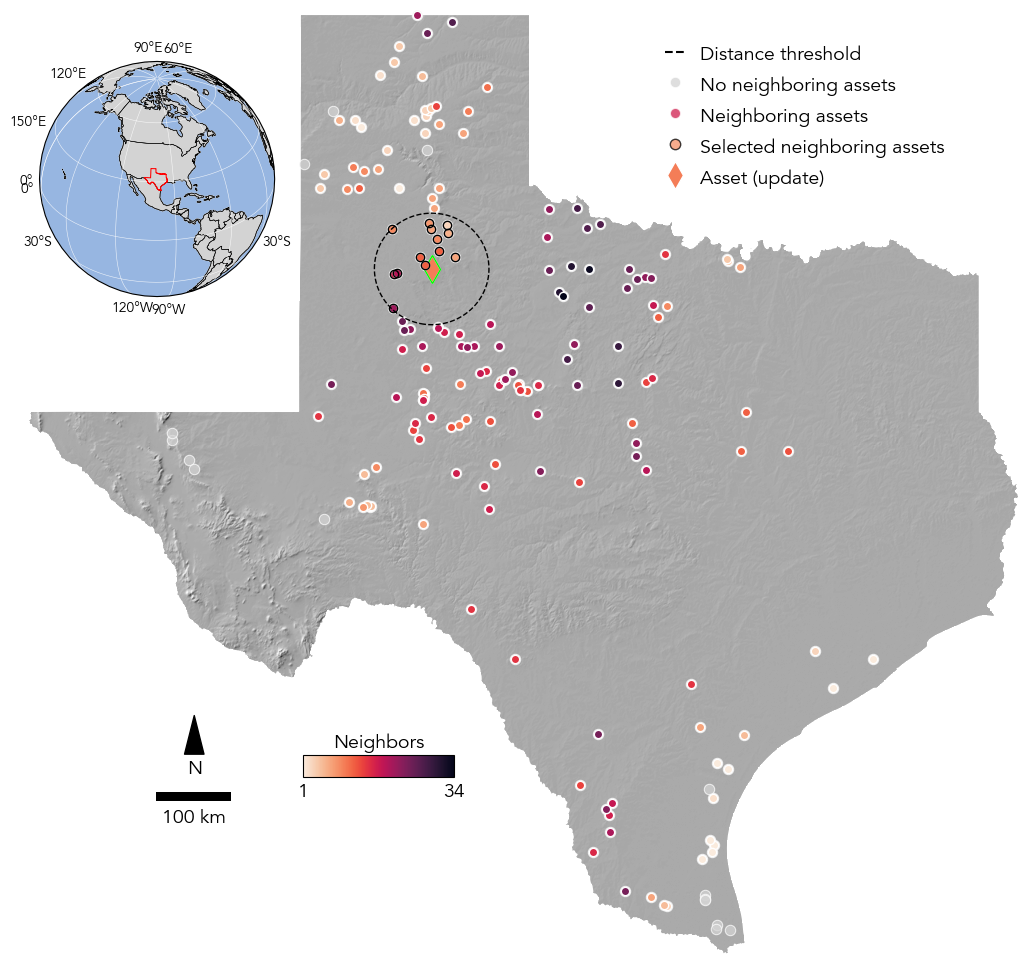

In [388]:
_fig, _ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")

# Add an inset globe showing Texas
plotter.globe_inset(
    _fig, _ax, _TX, 
    x0 = 0.005, 
    y0 = 0.7, 
    width = 0.25, 
    height = 0.25
)

_fig, _ax = plotter.hillshade(_fig, _ax, _TX)

plotter.plot_hillshade_frequency_map(
    _fig, _ax, palette_, _TX, _fdu, X_tr_, X_ts_, 
    _fdu.x_, 
    _fdu.idx_fed_,
    _fdu.idx_x_, 
    _fdu.r,
)

# Add compass (North arrow)
x = 0.1675
y = 0.2575
arrow_length = 0.06  # relative axes coords

_ax.annotate(
    "N",
    xy = (x, y),
    xytext = (x, y - arrow_length),
    arrowprops = dict(facecolor = "k", 
                      arrowstyle = "wedge,tail_width=1,shrink_factor=.5"),
    ha = "center",
    va = "center",
    fontsize = 14,
    xycoords = _ax.transAxes,
)

scalebar = ScaleBar(
    dx = 100,  # scaling factor
    units = "km",
    dimension = "si-length",  # could also be 'imperial-length.'
    location = "lower left",
    length_fraction = 0.09,  # fraction of the axis for bar length
    color = "black",
    box_color = "None",
    box_alpha = 1.0,
    border_pad = 9,
    font_properties = {"size": 14},
)

_ax.add_artist(scalebar)

_ax.legend(
    frameon = False, 
    bbox_to_anchor = (0.625, 0.9875), 
    ncol = 1, 
    fontsize = 14
)

plt.savefig(IMAGES / f"hillshade_neighboring_assets-{file_name}.pdf")

plt.show()

(3600, 72)
-0.06983024691357997 0.11766975308641969
[ 0.11766975 -0.06358025 -0.02337963 -0.01304012  0.02716049  0.06180556
  0.01095679 -0.06983025 -0.06003086  0.01226852]


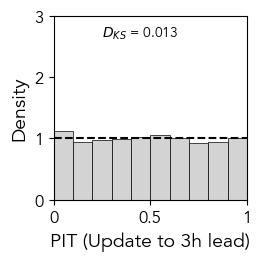

In [497]:
pit_ = loader.pit(
    _init, 
    resource, 
    method, 
    aggregation, 
    interval, 
    exp_description="unbiased-025",
    path_to_validation=VALIDATION
)

print(pit_.shape)

_fig, _ax = plt.subplots(
    figsize = (2.5, 2.5), 
    constrained_layout = True
)

lead = 0
bins = 10

plotter.plot_pit(
    _fig, _ax, pit_[:, lead*12:(lead + 3)*12].flatten(), 
    v = 0.4,
    bins = bins,
    xlabel = 'PIT (Update to 3h lead)'
)

plt.savefig(
    IMAGES / f"PIT-{resource}-{lead}-{bins}-{interval}.pdf"
)

plt.show()